In [1]:
# phase2_MMI_sweep.py
# MEEP 3D FDTD: sweep MMI length for 50/50 splitting at 1550 nm
# Reference geometry: [R6], waveguide from Phase 1

import meep as mp
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

Using MPI version 4.1, 1 processes


In [2]:

# ── Units: µm, c = 1 ───────────────────────────────────────────────────────
lam = 1.55
f0  = 1.0 / lam
df  = 0.15 / lam   # source bandwidth

# ── Materials ───────────────────────────────────────────────────────────────
LNO  = mp.Medium(epsilon_diag=mp.Vector3(2.138**2, 2.211**2, 2.211**2))
SiO2 = mp.Medium(index=1.444)


# ── Material indices at 1550 nm (Zelmon et al. 1997 [R5]) ──────────────────
n_e  = 2.138   # LNO extraordinary (TE mode, X-cut: c-axis along x)
n_o  = 2.211   # LNO ordinary
n_ox = 1.444   # SiO₂ BOX
n_air = 1.0

In [3]:

# ── Fixed geometry parameters ───────────────────────────────────────────────
h       = 0.30    # LNO core height
wg_w    = 0.90    # input/output waveguide width
W_MMI   = 5.5     # MMI body width (sweep W in a second pass if needed)
taper_L = 2.0     # linear taper length (wg_w → W_MMI at port)
port_off = W_MMI / 4  # = 1.375 µm — paired interference offset from center [R6]
pml_d   = 1.5     # PML thickness (µm)
wg_len  = 3.0     # input/output waveguide stub length beyond taper


In [4]:

def build_geometry(L_mmi, sx, sy, sz):
    """Build MEEP geometry list for 2×2 MMI with given body length."""
    x_mmi_c = 0.0    # MMI center at x = 0
    half_L  = L_mmi / 2

    geom = []

    # SiO₂ BOX (below LNO)
    geom.append(mp.Block(
        size=mp.Vector3(sx, sy, 2.0),
        center=mp.Vector3(0, 0, -(h/2 + 1.0)),
        material=SiO2
    ))

    # ── Input side (x < -half_L) ─────────────────────────────────────────
    # Upper input waveguide stub + taper
    x_in_wg_start = -(half_L + taper_L + wg_len)
    # Waveguide stub
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, +port_off, 0),
        material=LNO
    ))
    # Taper (approximated as block at full width — for accuracy use TrapezoidBlock
    # or break into small steps; sufficient for sweep at res=20)
    geom.append(mp.Block(
        size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
        center=mp.Vector3(-half_L - taper_L/2, +port_off/2, 0),
        material=LNO
    ))

    # Lower input waveguide (unused input port — terminated, or add second source)
    geom.append(mp.Block(
        size=mp.Vector3(wg_len, wg_w, h),
        center=mp.Vector3(x_in_wg_start + wg_len/2, -port_off, 0),
        material=LNO
    ))

    # ── MMI body ─────────────────────────────────────────────────────────
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI, h),
        center=mp.Vector3(0, 0, 0),
        material=LNO
    ))

    # ── Output side (x > +half_L) ─────────────────────────────────────────
    for sign in [+1, -1]:
        # Taper
        geom.append(mp.Block(
            size=mp.Vector3(taper_L, (wg_w + W_MMI/2)/2, h),
            center=mp.Vector3(+half_L + taper_L/2, sign * port_off/2, 0),
            material=LNO
        ))
        # Output waveguide stub
        geom.append(mp.Block(
            size=mp.Vector3(wg_len, wg_w, h),
            center=mp.Vector3(+half_L + taper_L + wg_len/2, sign * port_off, 0),
            material=LNO
        ))

    return geom



In [5]:
def run_mmi_sim(L_mmi, resolution=10):   # ← resolution 10, not 5
    stub = 4.0
    total_x = pml_d + stub + L_mmi + stub + pml_d
    sy_cell  = W_MMI + 6.0 + 2 * pml_d  # ← more padding around MMI

    cell    = mp.Vector3(total_x, sy_cell)
    half_tx = total_x / 2

    x_mmi_left  = -L_mmi / 2
    x_mmi_right = +L_mmi / 2

    geom = []

    # MMI body
    geom.append(mp.Block(
        size=mp.Vector3(L_mmi, W_MMI),
        center=mp.Vector3(0, 0),
        material=LNO,
    ))

    # BOTH input stubs — upper and lower
    for sign in [+1, -1]:
        geom.append(mp.Block(
            size=mp.Vector3(stub + pml_d, wg_w),
            center=mp.Vector3(x_mmi_left - (stub + pml_d)/2, sign * port_off),
            material=LNO,
        ))

    # Both output stubs
    for sign in [+1, -1]:
        geom.append(mp.Block(
            size=mp.Vector3(stub + pml_d, wg_w),
            center=mp.Vector3(x_mmi_right + (stub + pml_d)/2, sign * port_off),
            material=LNO,
        ))

    # Source placed well inside the upper input stub, away from MMI edge
    x_src = x_mmi_left - stub + 1.0    # ← 1 µm inside the stub, not 0.5
    src = [mp.EigenModeSource(
        src=mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, +port_off),
        size=mp.Vector3(0, wg_w + 0.5),  # ← tighter source, only 0.25 µm beyond wg edge
        eig_band=1,
        eig_parity=mp.NO_PARITY,
        direction=mp.X,
    )]

    x_mon = x_mmi_right + stub - 1.0   # ← monitor also pulled away from MMI edge
    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),
    )

    flux_upper = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, +port_off),
            size=mp.Vector3(0, wg_w + 0.5)
        ))
    flux_lower = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, -port_off),
            size=mp.Vector3(0, wg_w + 0.5)
        ))

    sim.run(until_after_sources=300)

    T_upper = mp.get_fluxes(flux_upper)[0]
    T_lower = mp.get_fluxes(flux_lower)[0]
    sim.reset_meep()
    return T_upper, T_lower

In [6]:
# ── Reference simulation (straight waveguide, for normalization) ──────────
###################### 2D #################################
def run_reference(resolution=5):
    ref_len = 20.0
    total_x = pml_d + wg_len + ref_len + wg_len + pml_d
    sy_c = wg_w + 3.0 + 2 * pml_d

    cell = mp.Vector3(total_x, sy_c)
    half_tx = total_x / 2
    x_src = -half_tx + pml_d + 0.5
    x_mon = +half_tx - pml_d - 0.5

    geom = [
        mp.Block(
            size=mp.Vector3(total_x, wg_w),
            center=mp.Vector3(0, 0),
            material=LNO
        ),
    ]

    src = [mp.EigenModeSource(
        mp.GaussianSource(f0, fwidth=df),
        center=mp.Vector3(x_src, 0),
        size=mp.Vector3(0, wg_w + 1.5),
        eig_band=1,
        eig_parity=mp.ODD_Y,
        direction=mp.X,
    )]

    sim = mp.Simulation(
        cell_size=cell,
        dimensions=2,
        boundary_layers=[mp.PML(pml_d)],
        geometry=geom,
        sources=src,
        resolution=resolution,
        default_material=mp.Medium(index=n_ox),
    )

    flux = sim.add_flux(f0, df, 100,
        mp.FluxRegion(
            center=mp.Vector3(x_mon, 0),
            size=mp.Vector3(0, wg_w + 1.0)
        ))

    sim.run(until_after_sources=500)  #hard cap

    P_ref = mp.get_fluxes(flux)[0]
    sim.reset_meep()
    return P_ref

In [ ]:

# ── Main sweep ─────────────────────────────────────────────────────────────
print("Running reference simulation...")
P_ref = run_reference(resolution=20)
print(f"P_ref = {P_ref:.6f}")

# L_sweep = np.arange(10, 56, 2)   # coarse: 10 to 54 µm in 2 µm steps
# L_sweep = np.arange(30, 85, 5)   # coarser steps, wider range, fewer points
# L_sweep = np.arange(28, 50, 2)   # 11 points, focused on the real peak
L_sweep = np.arange(28, 75, 3)   # 28, 31, 34 ... 73 → 16 points
# fine sweep around the crossing point
# L_sweep_fine = np.arange(L_cross - 4, L_cross + 4, 0.5)  # 16 points, 0.5 µm steps
T_upper_list, T_lower_list = [], []

print(f"\n{'L (µm)':>8}  {'T_upper':>9}  {'T_lower':>9}  {'T_total':>9}  {'ratio':>7}")
for L in L_sweep:
    tu, tl = run_mmi_sim(L, resolution=20)
    tu_norm = tu / P_ref
    tl_norm = tl / P_ref
    tt = tu_norm + tl_norm
    ratio = tu_norm / tt if tt > 0 else 0
    T_upper_list.append(tu_norm)
    T_lower_list.append(tl_norm)
    print(f"{L:>8.0f}  {tu_norm:>9.4f}  {tl_norm:>9.4f}  {tt:>9.4f}  {ratio:>7.3f}")

T_upper = np.array(T_upper_list)
T_lower = np.array(T_lower_list)
T_total = T_upper + T_lower
imbalance = np.abs(T_upper - T_lower)

# Candidate points: high total T and low imbalance
valid = T_total > 0.80 * np.max(T_total)
if valid.any():
    best_idx = np.argmin(imbalance[valid])
    best_L = L_sweep[valid][best_idx]
    print(f"\nCoarse optimum: L ≈ {best_L} µm")
    print(f"At best_L: T_upper={T_upper[valid][best_idx]:.4f}, "
          f"T_lower={T_lower[valid][best_idx]:.4f}")
else:
    print("No optimum found in sweep range — extend range!")
    best_L = None


Running reference simulation...
-----------
Initializing structure...
time for choose_chunkdivision = 0.000290572 s
Working in 2D dimensions.
Computational cell is 29 x 6.9 x 0 with resolution 20
     block, center = (0,0,0)
          size (29,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
time for set_epsilon = 0.139543 s
-----------
MPB solved for frequency_1(1.41022,0,0) = 0.676616 after 16 iters
MPB solved for frequency_1(1.33778,0,0) = 0.645199 after 7 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 3 iters
MPB solved for frequency_1(1.33769,0,0) = 0.645161 after 1 iters
Meep progress: 138.35/603.3333358764648 = 22.9% done in 4.0s, 13.4s to go
on time step 5534 (time=138.35), 0.000722876 s/step
Meep progress: 281.45/603.3333358764648 = 46.6% done in 8.0s, 9.2s to go
on time step 11259 (time=281.475), 0.000698774 s/step
Meep progress: 422.95000000000005/603.3333358764648 = 70.1% done in 12.0s

In [ ]:
# ── Fine sweep around best_L ────────────────────────────────────────────────
if best_L is not None:
    L_fine = np.linspace(best_L - 3, best_L + 3, 13)
    Tu_fine, Tl_fine = [], []
    for L in L_fine:
        tu, tl = run_mmi_sim(L, resolution=35)  # higher res for accuracy
        Tu_fine.append(tu / P_ref)
        Tl_fine.append(tl / P_ref)
    Tu_fine = np.array(Tu_fine)
    Tl_fine = np.array(Tl_fine)
    best_fine_idx = np.argmin(np.abs(Tu_fine - Tl_fine))
    L_opt = L_fine[best_fine_idx]
    IL_dB = -10 * np.log10(Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    split_pct = 100 * Tu_fine[best_fine_idx] / (Tu_fine[best_fine_idx] + Tl_fine[best_fine_idx])
    print(f"\nFine optimum: L_opt = {L_opt:.2f} µm")
    print(f"Split ratio: {split_pct:.1f}% / {100-split_pct:.1f}%")
    print(f"Insertion loss: {IL_dB:.2f} dB")
else:
    L_opt = None


-----------
Initializing structure...
time for choose_chunkdivision = 0.000593227 s
Working in 2D dimensions.
Computational cell is 38 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (29,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-16.75,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-16.75,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (16.75,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (16.75,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          di

MPB solved for frequency_1(1.41022,0,0) = 0.666053 after 28 iters
MPB solved for frequency_1(1.36305,0,0) = 0.645165 after 7 iters
MPB solved for frequency_1(1.36304,0,0) = 0.645161 after 2 iters
Meep progress: 11.957142857142857/403.33333587646484 = 3.0% done in 4.0s, 130.9s to go
on time step 837 (time=11.9571), 0.00477946 s/step
Meep progress: 24.514285714285712/403.33333587646484 = 6.1% done in 8.0s, 123.7s to go
on time step 1716 (time=24.5143), 0.00455356 s/step
Meep progress: 36.98571428571429/403.33333587646484 = 9.2% done in 12.0s, 118.9s to go
on time step 2589 (time=36.9857), 0.00458498 s/step
Meep progress: 49.41428571428571/403.33333587646484 = 12.3% done in 16.0s, 114.7s to go
on time step 3459 (time=49.4143), 0.00460052 s/step
Meep progress: 61.68571428571428/403.33333587646484 = 15.3% done in 20.0s, 110.8s to go
on time step 4319 (time=61.7), 0.00465679 s/step
Meep progress: 74.2/403.33333587646484 = 18.4% done in 24.0s, 106.5s to go
on time step 5195 (time=74.2143), 0.

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000569593 s
Working in 2D dimensions.
Computational cell is 38.5143 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (29.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-17,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-17,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (17,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (17,-1.375,0)
          size (4.5,0.9,0)

MPB solved for frequency_1(1.41022,0,0) = 0.666053 after 28 iters
MPB solved for frequency_1(1.36305,0,0) = 0.645165 after 7 iters
MPB solved for frequency_1(1.36304,0,0) = 0.645161 after 2 iters
Meep progress: 12.128571428571428/403.33333587646484 = 3.0% done in 4.0s, 129.1s to go
on time step 849 (time=12.1286), 0.00471274 s/step
Meep progress: 24.557142857142857/403.33333587646484 = 6.1% done in 8.0s, 123.4s to go
on time step 1719 (time=24.5571), 0.00459826 s/step
Meep progress: 36.92857142857143/403.33333587646484 = 9.2% done in 12.0s, 119.1s to go
on time step 2585 (time=36.9286), 0.00462286 s/step
Meep progress: 49.214285714285715/403.33333587646484 = 12.2% done in 16.0s, 115.2s to go
on time step 3445 (time=49.2143), 0.00465201 s/step
Meep progress: 61.44285714285714/403.33333587646484 = 15.2% done in 20.0s, 111.3s to go
on time step 4301 (time=61.4429), 0.00467533 s/step
Meep progress: 73.74285714285715/403.33333587646484 = 18.3% done in 24.0s, 107.3s to go
on time step 5162 (

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000567149 s
Working in 2D dimensions.
Computational cell is 39 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (30,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-17.25,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-17.25,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (17.25,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (17.25,-1.375,0)
          size (4.5,0

...

MPB solved for frequency_1(1.41022,0,0) = 0.666053 after 28 iters
MPB solved for frequency_1(1.36305,0,0) = 0.645165 after 7 iters
MPB solved for frequency_1(1.36304,0,0) = 0.645161 after 2 iters
Meep progress: 10.242857142857142/403.33333587646484 = 2.5% done in 4.0s, 153.6s to go
on time step 717 (time=10.2429), 0.00558121 s/step
Meep progress: 21.142857142857142/403.33333587646484 = 5.2% done in 8.0s, 144.7s to go
on time step 1480 (time=21.1429), 0.0052471 s/step
Meep progress: 31.885714285714286/403.33333587646484 = 7.9% done in 12.0s, 139.9s to go
on time step 2233 (time=31.9), 0.00531852 s/step
Meep progress: 42.785714285714285/403.33333587646484 = 10.6% done in 16.0s, 134.9s to go
on time step 2996 (time=42.8), 0.00524811 s/step
Meep progress: 53.72857142857143/403.33333587646484 = 13.3% done in 20.0s, 130.2s to go
on time step 3763 (time=53.7571), 0.00521934 s/step
Meep progress: 64.74285714285715/403.33333587646484 = 16.1% done in 24.0s, 125.6s to go
on time step 4534 (time=6

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000580464 s
Working in 2D dimensions.
Computational cell is 43.5143 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (34.5,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-19.5,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-19.5,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (19.5,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (19.5,-1.375,0)
          size (4.

MPB solved for frequency_1(1.41022,0,0) = 0.666053 after 28 iters
MPB solved for frequency_1(1.36305,0,0) = 0.645165 after 7 iters
MPB solved for frequency_1(1.36304,0,0) = 0.645161 after 2 iters
Meep progress: 10.157142857142857/403.33333587646484 = 2.5% done in 4.0s, 154.9s to go
on time step 711 (time=10.1571), 0.005629 s/step
Meep progress: 20.9/403.33333587646484 = 5.2% done in 8.0s, 146.5s to go
on time step 1463 (time=20.9), 0.0053207 s/step
Meep progress: 31.84285714285714/403.33333587646484 = 7.9% done in 12.0s, 140.1s to go
on time step 2229 (time=31.8429), 0.00522778 s/step
Meep progress: 42.58571428571428/403.33333587646484 = 10.6% done in 16.0s, 135.6s to go
on time step 2981 (time=42.5857), 0.00532362 s/step
Meep progress: 53.4/403.33333587646484 = 13.2% done in 20.0s, 131.2s to go
on time step 3738 (time=53.4), 0.00528927 s/step
Meep progress: 64.11428571428571/403.33333587646484 = 15.9% done in 24.0s, 127.1s to go
on time step 4488 (time=64.1143), 0.00533484 s/step
Meep

run 0 finished at t = 403.34285714285716 (28234 timesteps)
-----------
Initializing structure...
time for choose_chunkdivision = 0.000587577 s
Working in 2D dimensions.
Computational cell is 44 x 12.5143 x 0 with resolution 35
     block, center = (0,0,0)
          size (35,5.5,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-19.75,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (-19.75,-1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (19.75,1.375,0)
          size (4.5,0.9,0)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (4.57104,4.88852,4.88852)
     block, center = (19.75,-1.375,0)
          size (4.5,0

MPB solved for frequency_1(1.41022,0,0) = 0.666053 after 28 iters
MPB solved for frequency_1(1.36305,0,0) = 0.645165 after 7 iters
MPB solved for frequency_1(1.36304,0,0) = 0.645161 after 2 iters
Meep progress: 9.985714285714286/403.33333587646484 = 2.5% done in 4.0s, 157.6s to go
on time step 699 (time=9.98571), 0.00572381 s/step
Meep progress: 20.385714285714286/403.33333587646484 = 5.1% done in 8.0s, 150.3s to go
on time step 1427 (time=20.3857), 0.0054973 s/step
Meep progress: 30.985714285714284/403.33333587646484 = 7.7% done in 12.0s, 144.3s to go
on time step 2169 (time=30.9857), 0.00539585 s/step
Meep progress: 41.65714285714286/403.33333587646484 = 10.3% done in 16.0s, 139.0s to go
on time step 2917 (time=41.6714), 0.00535441 s/step
Meep progress: 52.17142857142857/403.33333587646484 = 12.9% done in 20.0s, 134.7s to go
on time step 3653 (time=52.1857), 0.00543716 s/step
Meep progress: 62.8/403.33333587646484 = 15.6% done in 24.0s, 130.2s to go
on time step 4397 (time=62.8143), 

In [ ]:


# ── Save ─────────────────────────────────────────────────────────────────────
scipy.io.savemat('MMI_transmission_3.mat', {
    'L_sweep': L_sweep,
    'T_upper': T_upper, 'T_lower': T_lower, 'T_total': T_total,
    'L_opt': L_opt if L_opt else 0,
})
print("\nSaved: MMI_transmission_3.mat")




Saved: MMI_transmission_2.mat


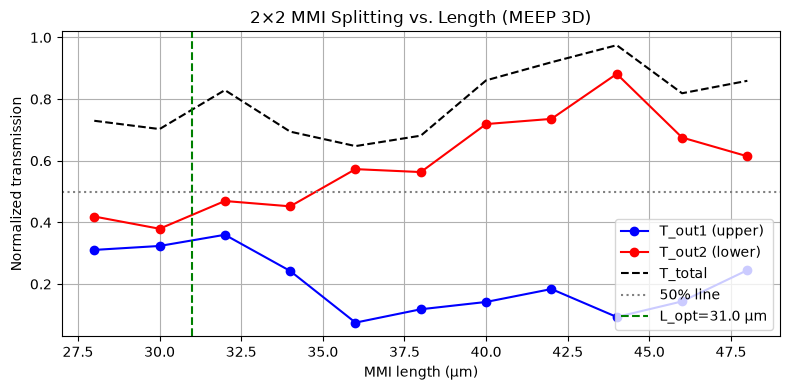

In [ ]:
# ── Plot ─────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(L_sweep, T_upper, 'b-o', label='T_out1 (upper)')
plt.plot(L_sweep, T_lower, 'r-o', label='T_out2 (lower)')
plt.plot(L_sweep, T_total, 'k--', label='T_total')
plt.axhline(0.5, color='gray', linestyle=':', label='50% line')
if L_opt: plt.axvline(L_opt, color='green', linestyle='--', label=f'L_opt={L_opt:.1f} µm')
plt.xlabel('MMI length (µm)')
plt.ylabel('Normalized transmission')
plt.title('2×2 MMI Splitting vs. Length (MEEP 3D)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('mmi_sweep_3.png', dpi=150)